In [141]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, silhouette_score)


In [120]:
TARGET = "Response"
RANDOM_STATE = 42
TEST_SIZE = 0.2
PCA_VARIANCE = 0.95          # keep components explaining 95% variance
K_OVERRIDE = None            # set e.g. 4 to force k for K-Means; None = pick by silhouette
N_SEEDS = 5                  # extra repeated splits to check stability; set 0 to skip
REF_DATE = pd.Timestamp("2014-07-01")   # dataset was collected around mid-2014

SPEND_COLS = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
              "MntSweetProducts", "MntGoldProds"]
CHANNEL_COLS = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
CAMPAIGN_COLS = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]

In [121]:
df = pd.read_csv("/Users/saloniagrawal/Downloads/marketing_campaign.csv", sep=None, engine="python")  
print("Shape:", df.shape)
print(df.head())
df.info()
print("\nMissing values:\n", df.isnull().sum()[lambda s: s > 0])
print("\nTarget distribution:\n", df[TARGET].value_counts(normalize=True).round(3))

Shape: (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0  5524        1957  Graduation         Single  58138.0        0         0  04-09-2012       58       635  ...                  7             0             0             0             0   
1  2174        1954  Graduation         Single  46344.0        1         1  08-03-2014       38        11  ...                  5             0             0             0             0   
2  4141        1965  Graduation       Together  71613.0        0         0  21-08-2013       26       426  ...                  4             0             0             0             0   
3  6182        1984  Graduation       Together  26646.0        1         0  10-02-2014       26        11  ...                  6             0             0             0             0   
4  5324        1981         PhD      

In [122]:
#removing the useless columns 
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"], errors="ignore")

In [123]:
df.shape

(2240, 26)

In [124]:
#removing duplicate values
before = len(df)
df = df.drop_duplicates()
print(f"\nDuplicates removed: {before - len(df)}")


Duplicates removed: 182


In [125]:
#encoding categorial columns 
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Single", "Divorced": "Single", "Widow": "Single",
    "Alone": "Single", "Absurd": "Single", "YOLO": "Single"})
df["Living_With_Partner"] = (df["Marital_Status"] == "Partner").astype(int)
df = df.drop(columns="Marital_Status")


edu_map = {"Basic": 0, "Graduation": 1, "2n Cycle": 2, "Master": 2, "PhD": 3}
df["Education"] = df["Education"].map(edu_map)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [126]:
df.head

<bound method NDFrame.head of       Year_Birth  Education    Income  Kidhome  Teenhome Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  ...  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  \
0           1957          1   58138.0        0         0  2012-09-04       58       635         88              546  ...                  4                  7             0             0   
1           1954          1   46344.0        1         1  2014-03-08       38        11          1                6  ...                  2                  5             0             0   
2           1965          1   71613.0        0         0  2013-08-21       26       426         49              127  ...                 10                  4             0             0   
3           1984          1   26646.0        1         0  2014-02-10       26        11          4               20  ...                  4                  6             0             0   
4           1981    

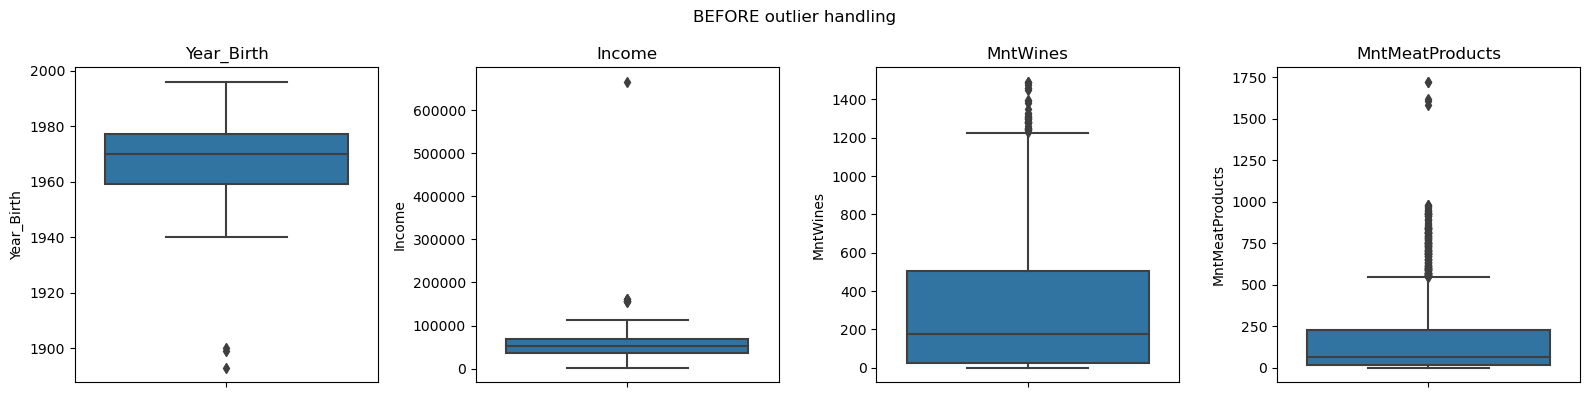

In [127]:
def show_boxplots(d, cols, title):
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4))
    for ax, c in zip(axes, cols):
        sns.boxplot(y=d[c], ax=ax)
        ax.set_title(c)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    
show_boxplots(df, ["Year_Birth", "Income", "MntWines", "MntMeatProducts"], "BEFORE outlier handling")


In [128]:
rows_before = len(df)
df = df[df["Year_Birth"] >= 1930]
q1, q3 = df["Income"].quantile([0.25, 0.75])
income_upper = q3 + (3 * (q3 - q1))
df = df[df["Income"].isna() | (df["Income"] <= income_upper)]
df = df.reset_index(drop=True)
print(f"Rows removed as outliers: {rows_before - len(df)} (Income upper fence = {income_upper:,.0f})")

Rows removed as outliers: 4 (Income upper fence = 167,452)


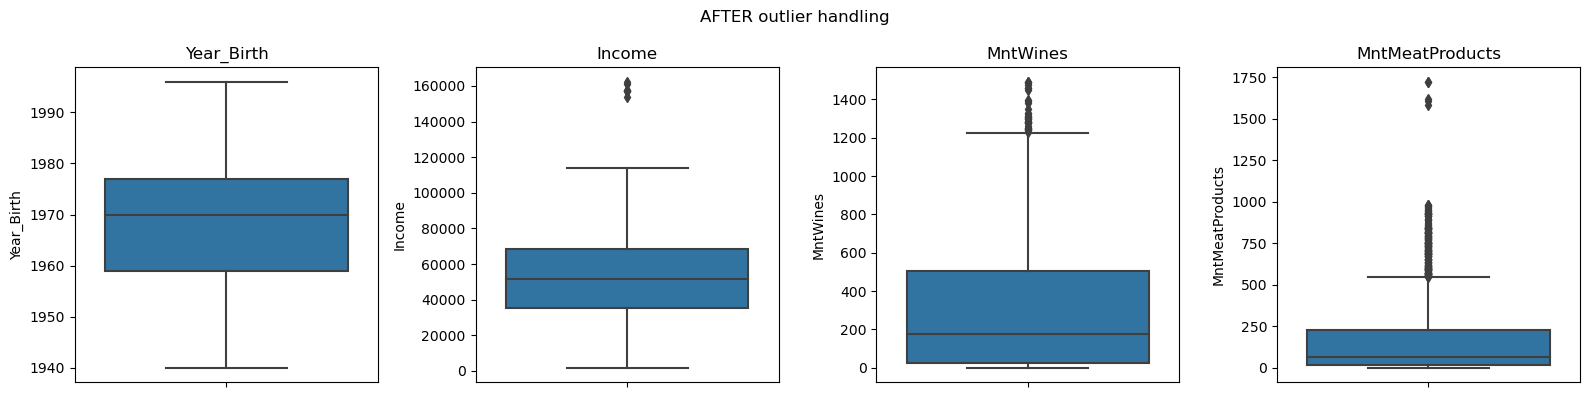

In [129]:
show_boxplots(df, ["Year_Birth", "Income", "MntWines", "MntMeatProducts"], "AFTER outlier handling")

In [130]:
print("\nRemaining missing values:\n", df.isnull().sum()[lambda s: s > 0])

X = df.drop(columns=TARGET)
y = df[TARGET]
print("\nFinal cleaned shape:", X.shape, "| positive rate:", round(y.mean(), 3))


Remaining missing values:
 Income    24
dtype: int64

Final cleaned shape: (2054, 25) | positive rate: 0.152


In [131]:
def impute_income(train, test):
    median = train["Income"].median()
    return train.fillna({"Income": median}), test.fillna({"Income": median})

In [132]:
def add_features(d):
    """Feature engineering (row-wise only, so no leakage)."""
    d = d.copy()
    d["Age"] = REF_DATE.year - d["Year_Birth"]
    d["Customer_Days"] = (REF_DATE - d["Dt_Customer"]).dt.days
    d["Total_Spent"] = d[SPEND_COLS].sum(axis=1)
    d["Total_Purchases"] = d[CHANNEL_COLS].sum(axis=1)
    d["Family_Size"] = 1 + d["Living_With_Partner"] + d["Kidhome"] + d["Teenhome"]
    d["Has_Children"] = ((d["Kidhome"] + d["Teenhome"]) > 0).astype(int)
    d["Income_Per_Person"] = d["Income"] / d["Family_Size"]
    d["Avg_Spend_Per_Purchase"] = (d["Total_Spent"] / d["Total_Purchases"].replace(0, np.nan)).fillna(0)
    d["Wine_Share"] = (d["MntWines"] / d["Total_Spent"].replace(0, np.nan)).fillna(0)
    d["Web_Purchase_Share"] = (d["NumWebPurchases"] / d["Total_Purchases"].replace(0, np.nan)).fillna(0)
    d["Past_Campaigns_Accepted"] = d[CAMPAIGN_COLS].sum(axis=1)
    return d.drop(columns=["Year_Birth", "Dt_Customer"])   # replaced by Age / Customer_Days

In [133]:
def scale_data(Xtr, Xte, use_yeo_johnson, verbose=False):
    """Optional Yeo-Johnson on skewed continuous columns, then StandardScaler."""
    Xtr, Xte = Xtr.copy(), Xte.copy()
    if use_yeo_johnson:
        # continuous-ish columns only (skip binary / tiny-count columns), skewed on TRAIN
        skewed = [c for c in Xtr.columns
                  if Xtr[c].nunique() > 10 and abs(Xtr[c].skew()) > 0.75]
        pt = PowerTransformer(method="yeo-johnson", standardize=False)
        Xtr[skewed] = pt.fit_transform(Xtr[skewed])
        Xte[skewed] = pt.transform(Xte[skewed])
        if verbose:
            print(f"Yeo-Johnson applied to {len(skewed)} skewed columns: {skewed}")
    sc = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xte)

/Users/saloniagrawal/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


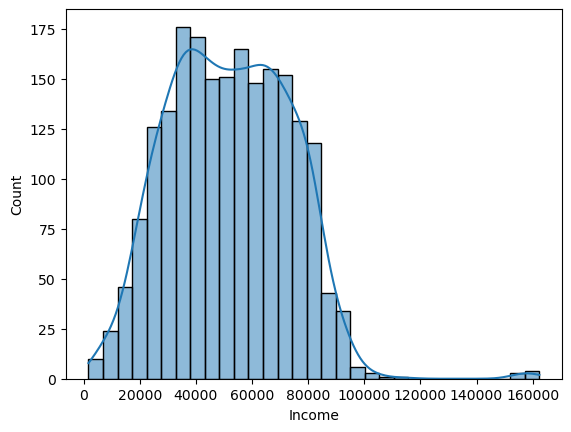

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Income"], kde=True)
plt.show()

In [135]:
def apply_pca(Xtr, Xte, seed, verbose=False, title=""):
    pca = PCA(n_components=PCA_VARIANCE, random_state=seed)
    Ptr = pca.fit_transform(Xtr)
    Pte = pca.transform(Xte)
    if verbose:
        full = PCA(random_state=seed).fit(Xtr)
        cum = np.cumsum(full.explained_variance_ratio_)
        plt.figure(figsize=(6, 4))
        plt.plot(range(1, len(cum) + 1), cum, marker="o")
        plt.axhline(PCA_VARIANCE, color="red", linestyle="--")
        plt.xlabel("Number of components")
        plt.ylabel("Cumulative explained variance")
        plt.title(f"Scree plot {title}")
        plt.show()
        print(f"PCA {title}: {Xtr.shape[1]} features -> {pca.n_components_} components")
    return Ptr, Pte

In [136]:
def add_kmeans_feature(Xtr, Xte, seed, verbose=False, title=""):
    """Fit K-Means on TRAIN (no target used), add one-hot cluster label to both sets."""
    ks = range(2, 9)
    inertia, sil = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(Xtr)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(Xtr, km.labels_))
    best_k = K_OVERRIDE if K_OVERRIDE else list(ks)[int(np.argmax(sil))]

    if verbose:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(list(ks), inertia, marker="o")
        axes[0].set_title(f"Elbow (inertia) {title}")
        axes[0].set_xlabel("k")
        axes[1].plot(list(ks), sil, marker="o")
        axes[1].set_title("Silhouette score")
        axes[1].set_xlabel("k")
        plt.tight_layout()
        plt.show()
        print(f"K-Means {title}: chosen k = {best_k}")

    km = KMeans(n_clusters=best_k, n_init=10, random_state=seed).fit(Xtr)
    tr_labels = km.labels_
    te_labels = km.predict(Xte)
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    tr_oh = ohe.fit_transform(tr_labels.reshape(-1, 1))
    te_oh = ohe.transform(te_labels.reshape(-1, 1))
    return np.hstack([Xtr, tr_oh]), np.hstack([Xte, te_oh]), tr_labels


In [137]:
def evaluate_models(Xtr, Xte, ytr, yte, exp_name, seed):
    """Tune KNN and SVM with 5-fold CV on train (scoring = ROC-AUC), score on the untouched test set."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    models = {
        "KNN": (KNeighborsClassifier(),
                {"n_neighbors": [5, 9, 15, 21, 31], "weights": ["uniform", "distance"]}),
        "SVM": (SVC(kernel="rbf", class_weight="balanced"),
                {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.001]}),
    }
    rows = []
    for name, (model, grid) in models.items():
        gs = GridSearchCV(model, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
        gs.fit(Xtr, ytr)
        best = gs.best_estimator_
        pred = best.predict(Xte)
        score = best.predict_proba(Xte)[:, 1] if hasattr(best, "predict_proba") else best.decision_function(Xte)
        rows.append({
            "Experiment": exp_name, "Model": name, "Features": Xtr.shape[1],
            "Accuracy": accuracy_score(yte, pred),
            "Precision": precision_score(yte, pred, zero_division=0),
            "Recall": recall_score(yte, pred, zero_division=0),
            "F1": f1_score(yte, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(yte, score),
            "PR_AUC": average_precision_score(yte, score),
        })
    return rows

In [138]:
def run_all(seed, verbose=False):
    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    Xtr_raw, Xte_raw = impute_income(Xtr_raw, Xte_raw)
    results = []

    # ---- 0. Baseline: cleaned data + scaling only ----
    base_tr = Xtr_raw.drop(columns="Dt_Customer")
    base_te = Xte_raw.drop(columns="Dt_Customer")
    A_tr, A_te = scale_data(base_tr, base_te, use_yeo_johnson=False)
    results += evaluate_models(A_tr, A_te, ytr, yte, "0. Baseline (clean + scale)", seed)

    # ---- 1. Feature engineering + Yeo-Johnson ----
    fe_tr, fe_te = add_features(Xtr_raw), add_features(Xte_raw)
    B_tr, B_te = scale_data(fe_tr, fe_te, use_yeo_johnson=True, verbose=verbose)
    results += evaluate_models(B_tr, B_te, ytr, yte, "1. Feature Eng + Yeo-Johnson", seed)

    # ---- 2. PCA only (on baseline features) ----
    C_tr, C_te = apply_pca(A_tr, A_te, seed, verbose, title="(baseline features)")
    results += evaluate_models(C_tr, C_te, ytr, yte, "2. PCA only", seed)

    # ---- 3. K-Means cluster feature only (on baseline features) ----
    D_tr, D_te, labels = add_kmeans_feature(A_tr, A_te, seed, verbose, title="(baseline features)")
    results += evaluate_models(D_tr, D_te, ytr, yte, "3. K-Means feature only", seed)
    if verbose:
        prof = fe_tr.assign(Cluster=labels, Response_Rate=ytr.values)
        summary = prof.groupby("Cluster").agg(
            Customers=("Income", "size"), Income=("Income", "mean"),
            Total_Spent=("Total_Spent", "mean"), Age=("Age", "mean"),
            Family_Size=("Family_Size", "mean"), Response_Rate=("Response_Rate", "mean")).round(2)
        print("\nCluster profile (train set) -> does Response_Rate differ across clusters?\n", summary)

    # ---- 4. Everything combined: FE + YJ -> PCA -> K-Means on PCA space ----
    E_tr, E_te = apply_pca(B_tr, B_te, seed, verbose, title="(FE + Yeo-Johnson features)")
    E_tr, E_te, _ = add_kmeans_feature(E_tr, E_te, seed, verbose, title="(on PCA space)")
    results += evaluate_models(E_tr, E_te, ytr, yte, "4. All combined", seed)

    return pd.DataFrame(results)


In [139]:
def evaluate_models(Xtr, Xte, ytr, yte, exp_name, seed):
    """Tune KNN, SVM, Logistic Regression and Decision Tree with 5-fold CV on
    train (scoring = ROC-AUC), score on the untouched test set."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    models = {
        "KNN": (KNeighborsClassifier(),
                {"n_neighbors": [5, 9, 15, 21, 31], "weights": ["uniform", "distance"]}),
        "SVM": (SVC(kernel="rbf", class_weight="balanced", probability=True),
                {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.001]}),
        # Reference models: not part of the preprocessing ablation story,
        # just here to show whether KNN/SVM's numbers are actually good.
        "LogisticRegression": (LogisticRegression(class_weight="balanced", max_iter=2000),
                {"C": [0.01, 0.1, 1, 10]}),
        "DecisionTree": (DecisionTreeClassifier(class_weight="balanced", random_state=seed),
                {"max_depth": [3, 5, 8, None], "min_samples_leaf": [1, 5, 10, 20]}),
    }
    rows = []
    for name, (model, grid) in models.items():
        gs = GridSearchCV(model, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
        gs.fit(Xtr, ytr)
        best = gs.best_estimator_
        pred = best.predict(Xte)
        score = best.predict_proba(Xte)[:, 1] if hasattr(best, "predict_proba") else best.decision_function(Xte)
        rows.append({
            "Experiment": exp_name, "Model": name, "Features": Xtr.shape[1],
            "Accuracy": accuracy_score(yte, pred),
            "Precision": precision_score(yte, pred, zero_division=0),
            "Recall": recall_score(yte, pred, zero_division=0),
            "F1": f1_score(yte, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(yte, score),
            "PR_AUC": average_precision_score(yte, score),
        })
    return rows

Yeo-Johnson applied to 12 skewed columns: ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'Total_Spent', 'Income_Per_Person', 'Avg_Spend_Per_Purchase']


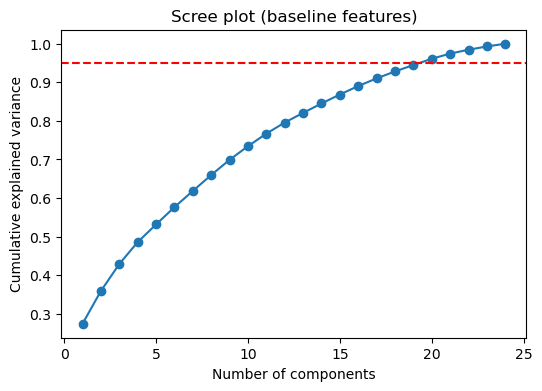

PCA (baseline features): 24 features -> 20 components


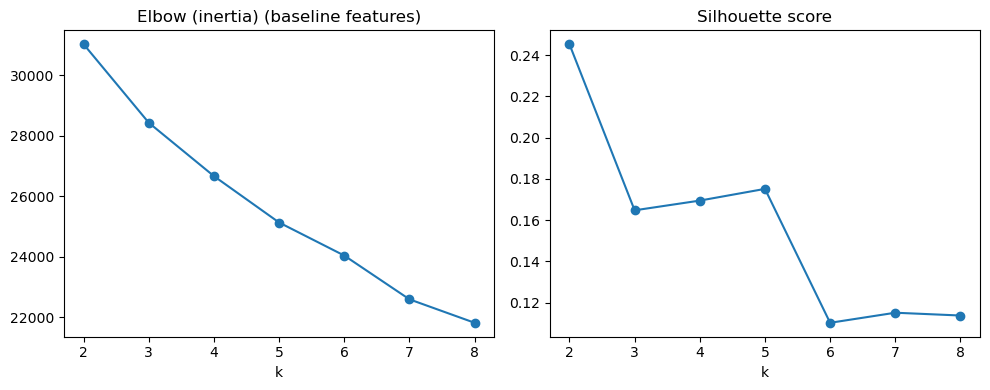

K-Means (baseline features): chosen k = 2

Cluster profile (train set) -> does Response_Rate differ across clusters?
          Customers    Income  Total_Spent    Age  Family_Size  Response_Rate
Cluster                                                                     
0              667  71384.75      1219.02  47.15         2.14           0.22
1              976  38560.14       180.93  43.48         2.90           0.11


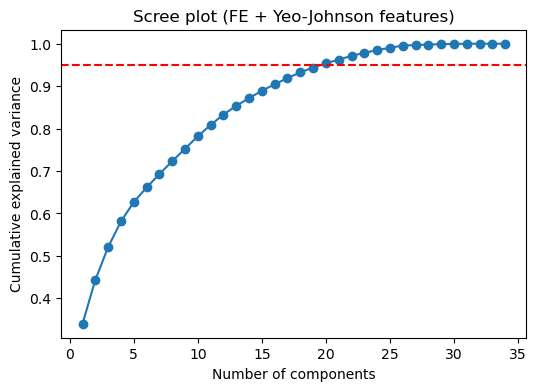

PCA (FE + Yeo-Johnson features): 34 features -> 20 components


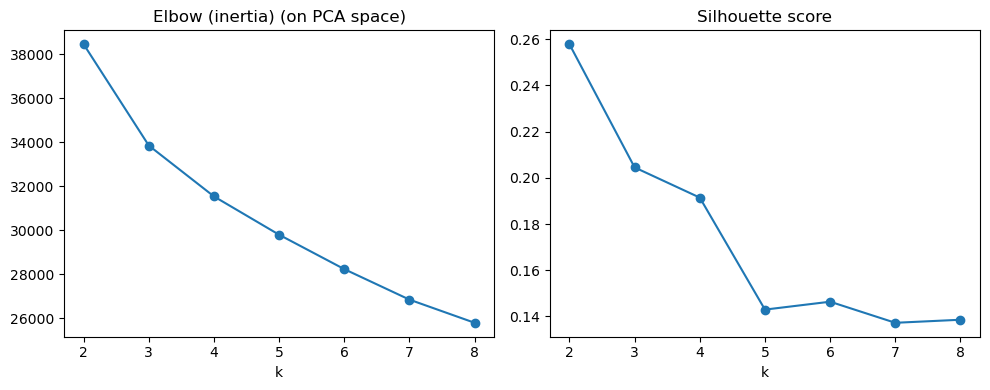

K-Means (on PCA space): chosen k = 2

=== RESULTS (seed = 42 ) ===
                  Experiment              Model  Features  Accuracy  Precision  Recall    F1  ROC_AUC  PR_AUC   d_F1  d_ROC_AUC  d_PR_AUC
 0. Baseline (clean + scale)                KNN        24     0.866      0.786   0.175 0.286    0.868   0.572  0.000      0.000     0.000
 0. Baseline (clean + scale)                SVM        24     0.830      0.468   0.825 0.598    0.893   0.635  0.000      0.000     0.000
 0. Baseline (clean + scale) LogisticRegression        24     0.798      0.415   0.778 0.541    0.880   0.618  0.000      0.000     0.000
 0. Baseline (clean + scale)       DecisionTree        24     0.757      0.354   0.714 0.474    0.806   0.437  0.000      0.000     0.000
1. Feature Eng + Yeo-Johnson                KNN        34     0.871      0.812   0.206 0.329    0.896   0.636  0.043      0.028     0.064
1. Feature Eng + Yeo-Johnson                SVM        34     0.835      0.478   0.873 0.618    0.915   0

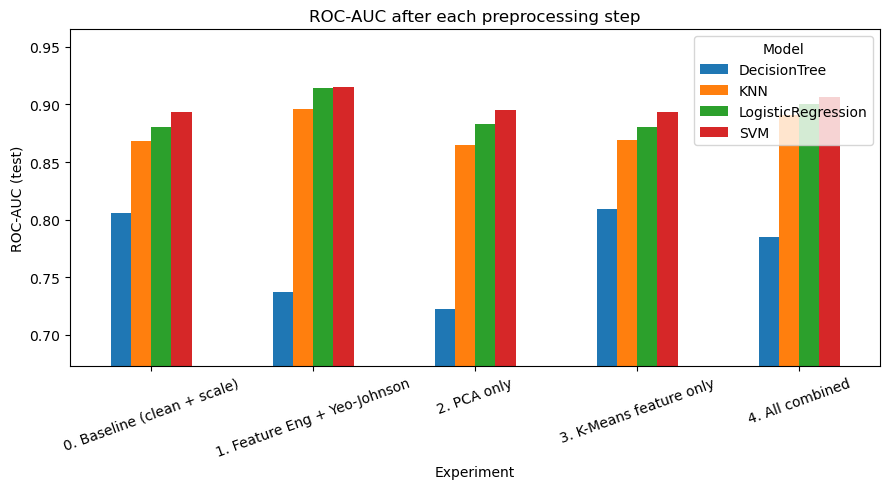

In [142]:
res = run_all(RANDOM_STATE, verbose=True)

# improvement over baseline (baseline is the first row of each model)
for metric in ["F1", "ROC_AUC", "PR_AUC"]:
    res[f"d_{metric}"] = res[metric] - res.groupby("Model")[metric].transform("first")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
print("\n=== RESULTS (seed =", RANDOM_STATE, ") ===")
print(res.round(3).to_string(index=False))
print("\nReference: a useless model has PR_AUC about", round(y.mean(), 3), "and ROC_AUC 0.5")
res.to_csv("results_single_split.csv", index=False)

auc_table = res.pivot(index="Experiment", columns="Model", values="ROC_AUC")
auc_table.plot(kind="bar", figsize=(9, 5), rot=20)
plt.ylabel("ROC-AUC (test)")
plt.title("ROC-AUC after each preprocessing step")
plt.ylim(max(0, auc_table.min().min() - 0.05), min(1, auc_table.max().max() + 0.05))
plt.tight_layout()
plt.show()

In [143]:
if N_SEEDS > 0:
    runs = pd.concat([run_all(s).assign(Seed=s) for s in range(N_SEEDS)], ignore_index=True)
    summary = (runs.groupby(["Model", "Experiment"], sort=False)[["Accuracy", "F1", "ROC_AUC", "PR_AUC"]]
                   .agg(["mean", "std"]).round(3))
    print(f"\n=== MEAN +- STD over {N_SEEDS} random splits ===")
    print(summary)
    runs.to_csv("results_multi_seed.csv", index=False)



=== MEAN +- STD over 5 random splits ===
                                                Accuracy            F1        ROC_AUC        PR_AUC       
                                                    mean    std   mean    std    mean    std   mean    std
Model              Experiment                                                                             
KNN                0. Baseline (clean + scale)     0.862  0.006  0.291  0.027   0.843  0.027  0.529  0.048
SVM                0. Baseline (clean + scale)     0.807  0.011  0.556  0.012   0.877  0.016  0.599  0.047
LogisticRegression 0. Baseline (clean + scale)     0.795  0.007  0.538  0.022   0.877  0.017  0.609  0.034
DecisionTree       0. Baseline (clean + scale)     0.762  0.021  0.463  0.033   0.790  0.033  0.422  0.064
KNN                1. Feature Eng + Yeo-Johnson    0.872  0.008  0.334  0.069   0.866  0.031  0.576  0.066
SVM                1. Feature Eng + Yeo-Johnson    0.840  0.014  0.600  0.022   0.903  0.012  0.664  0